In [24]:
pip install adjusttext

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from adjustText import adjust_text

In [26]:
# user-defined paths
base_dir = '../../../../datos-notebooks/1.global-data-cba/'
ground_data_name = 'ground_data_170226_validation_TAcorr.gpkg'
mrt_name = 'MRT_1m-15dif_distedif.tif' 

# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)
mrt_path = os.path.join(base_dir, 'MRT-prediction', mrt_name)

#### reading and calibrating ground data 

In [27]:
gdf = gpd.read_file(ground_data_path)

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:198: RuntimeWarning:

Non-conformant content for record 1 in column start, 2026-02-17T13:18:53.548-03:00, successfully parsed



In [28]:
# calibrate TG1
# from notebook 1.4.4.1. 
gdf["tg_corr"] = np.where(
    gdf["Instrument"] == "T1 - Sper Scientific 800036 ",
    0.639 * gdf["TG"] + 9.681,   # apply correction for T1
    gdf["TG"]                    # keep original value for T2
)

In [29]:
# calibrate wind speed
# from notebook 1.4.4.2.

t1 = gdf[gdf["Instrument"] == "T1 - Sper Scientific 800036 "]["WIND M/S"]
t2 = gdf[gdf["Instrument"] == "T2 - TM-188D TENMARS "]["WIND M/S"]

t1_min, t1_max = t1.min(), t1.max()
t2_min, t2_max = t2.min(), t2.max()

gdf.loc[gdf["Instrument"] == "T2 - TM-188D TENMARS ", "wind_norm"] = \
    t1_min + (t2 - t2_min) / (t2_max - t2_min) * (t1_max - t1_min)

# T1 stays the same
gdf.loc[gdf["Instrument"] == "T1 - Sper Scientific 800036 ", "wind_norm"] = t1.values


In [30]:
# compute mean of wind values in a time window
# because wind recorded is instantaneous, but TG is affected by wind conditions in the minutes before measurement


gdf["end"] = pd.to_datetime(gdf["end"], errors="coerce")

gdf = gdf.sort_values("end") # Sort by time
gdf = gdf.set_index("end") # Set as index

gdf["wind_mean"] = (
    gdf["wind_norm"]
    .rolling(window="10min", center=True, min_periods=1)
    .mean()
    .rolling(window="10min", center=True, min_periods=1)
    .mean()
    .round(2)
)


gdf = gdf.reset_index()

#### computing observed MRT and extracting predicted MRT values for ground data

In [31]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(gdf["Instrument"] == "T1 - Sper Scientific 800036 ", D1,D2)

# MRT calculation using row-specific diameter
gdf["MRT"] = (
    (
        (gdf["tg_corr"] + 273.15)**4
        + (1.1e8 * gdf["wind_mean"]**0.6 / (eps * D2**0.4)) * (gdf["tg_corr"] - gdf["TA"]) # use D2 because TG values are calibrated to Thermometer 2
    )**0.25
    - 273.15
)

In [32]:
# read raster crs and sample values
with rasterio.open(mrt_path) as src:
    mrt_crs = src.crs
    points_proj = gdf.to_crs(mrt_crs)
    samples = list(src.sample(zip(points_proj.geometry.x, points_proj.geometry.y)))
    points_proj['MRT_predicted'] = [s[0] for s in samples]

points_proj['MRT_predicted'] = points_proj['MRT_predicted'].astype(float) 
points_proj["ID"] = range(len(points_proj))

# export gpkg
out_gpkg = os.path.join(base_dir, 'MRT-prediction/MRT_points_2026v2.gpkg')
points_proj.to_file(out_gpkg, driver="GPKG")


In [33]:
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']
points_proj['residuals'] = obs - pred

In [34]:
points_proj

,end,start,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,...,picture 2_URL,context,tg_corr,wind_mean,MRT,geometry,wind_norm,MRT_predicted,ID,residuals
0,2026-02-17 13:40:22.997000-03:00,2026-02-17 13:38:25.282000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,29.3,31.6,2.7,-31.370683,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,31.6000,0.47,36.439988,POINT (381284.173 6528720.501),0.800000,34.642914,0,1.797075
1,2026-02-17 13:41:19.664000-03:00,2026-02-17 13:18:53.548000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,28.7,32.6,0.0,-31.370702,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,30.5124,0.45,34.287594,POINT (381282.355 6528723.634),0.000000,34.506630,1,-0.219036
2,2026-02-17 13:44:25.264000-03:00,2026-02-17 13:40:23.037000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,38.7000,0.45,54.334801,POINT (381240.071 6528640.976),0.474074,49.645077,2,4.689724
3,2026-02-17 13:45:54.242000-03:00,2026-02-17 13:41:19.707000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,28.9,42.2,0.7,-31.370663,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,36.6468,0.46,51.266906,POINT (381237.656 6528644.274),0.700000,48.886143,3,2.380763
4,2026-02-17 13:55:34.771000-03:00,2026-02-17 13:45:54.280000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,30.7,38.0,0.2,-31.366038,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,33.9630,0.43,40.279121,POINT (381888.001 6529164.351),0.200000,52.234322,4,-11.955201
5,2026-02-17 13:57:46.642000-03:00,2026-02-17 13:55:34.807000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,33.0,40.9,0.8,-31.366234,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,35.8161,0.45,41.339865,POINT (381871.888 6529142.441),0.800000,50.840950,5,-9.501085
6,2026-02-17 13:58:05.656000-03:00,2026-02-17 13:44:25.303000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,32.4,34.4,0.9,-31.361940,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,34.4000,0.45,38.406402,POINT (382446.075 6529619.412),0.266667,38.235901,6,0.170501
7,2026-02-17 14:00:37.725000-03:00,2026-02-17 13:58:05.712000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,34.0,38.6,1.6,-31.361905,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,38.6000,0.46,47.364822,POINT (382435.92 6529628.692),0.474074,53.746552,7,-6.381730
8,2026-02-17 14:07:42.166000-03:00,2026-02-17 13:57:46.678000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,30.2,42.7,0.3,-31.366936,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,36.9663,0.37,48.315229,POINT (381845.755 6529064.324),0.300000,48.832188,8,-0.516958
9,2026-02-17 14:09:42.460000-03:00,2026-02-17 14:00:37.766000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.9,33.0,1.0,-31.366773,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,33.0000,0.45,41.158479,POINT (383893.312 6528972.979),0.296296,34.380749,9,6.777730


#### analysis

In [35]:
# Metrics

residuals = obs - pred

mae = np.mean(np.abs(residuals)).round(2)
rmse = np.sqrt(np.mean(residuals**2)).round(2)
bias = np.mean(residuals).round(2)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 2.92
RMSE: 4.21
Bias: -0.98


In [36]:
# plot

# Scatter
fig = px.scatter(
    points_proj,
    x=points_proj['MRT'],
    y=points_proj['MRT_predicted'],
    color=abs(points_proj['residuals']),
    hover_data=["tg_corr", "TA","wind_mean", "Instrument", "condition", "residuals", "WIND M/S", "context"],
)

# 1:1 line
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    line=dict(color="black", width=2), 
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="observed vs predicted MRT", 
    coloraxis_colorbar=dict(title="Residuals")
)


fig.show()


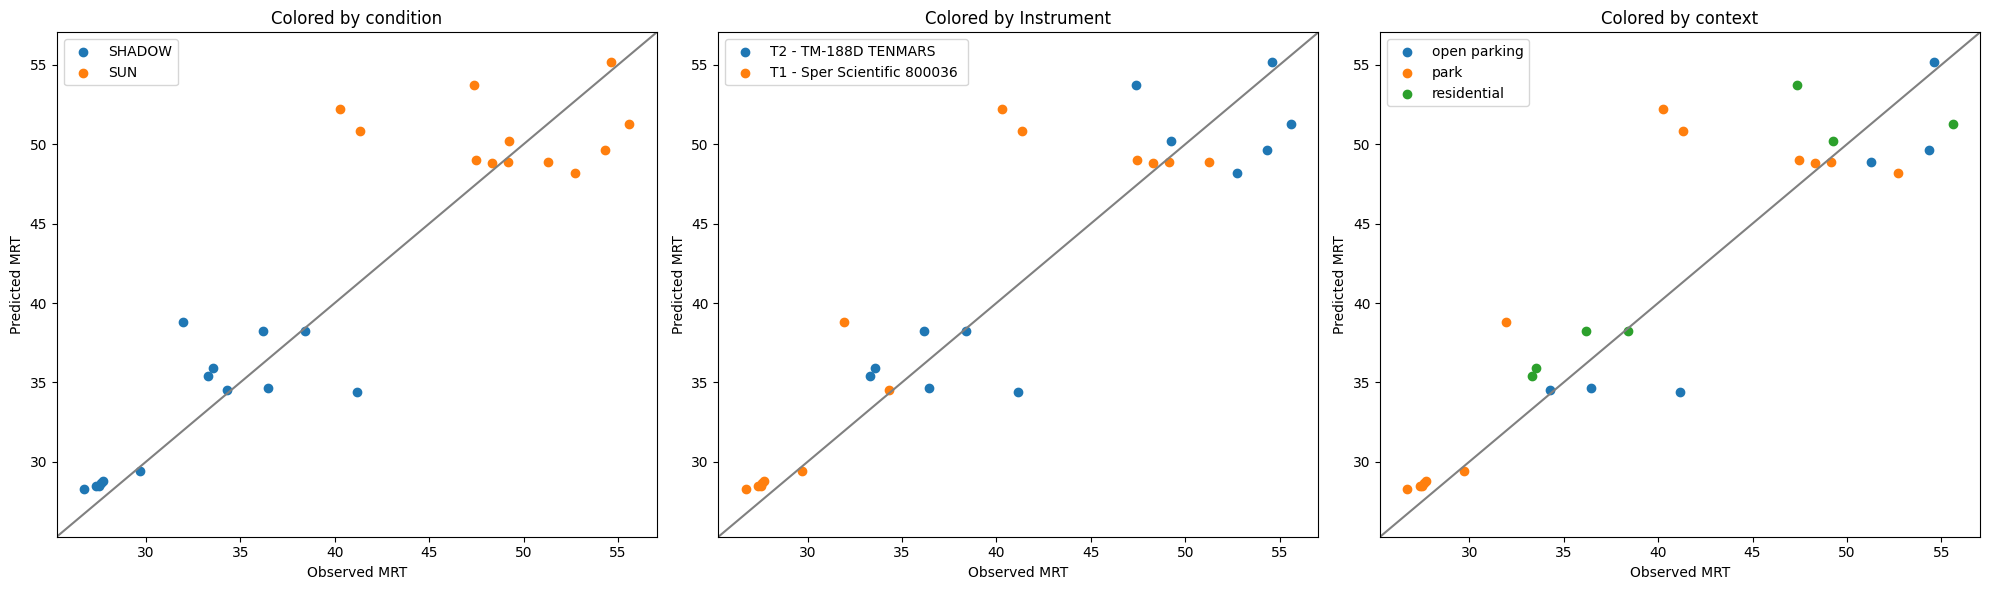

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Helper values
x = points_proj["MRT"]
y = points_proj["MRT_predicted"]

# 1) condition
for cond in points_proj["condition"].unique():
    mask = points_proj["condition"] == cond
    axes[0].scatter(x[mask], y[mask], label=cond)
axes[0].set_title("Colored by condition")
axes[0].set_xlabel("Observed MRT")
axes[0].set_ylabel("Predicted MRT")
axes[0].legend()


# 2) Instrument
for inst in points_proj["Instrument"].unique():
    mask = points_proj["Instrument"] == inst
    axes[1].scatter(x[mask], y[mask], label=inst)
axes[1].set_title("Colored by Instrument")
axes[1].set_xlabel("Observed MRT")
axes[1].set_ylabel("Predicted MRT")
axes[1].legend()


# 3) context
for ctx in points_proj["context"].unique():
    mask = points_proj["context"] == ctx
    axes[2].scatter(x[mask], y[mask], label=ctx)
axes[2].set_title("Colored by context")
axes[2].set_xlabel("Observed MRT")
axes[2].set_ylabel("Predicted MRT")
axes[2].legend()


# 1:1 reference line
for ax in axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

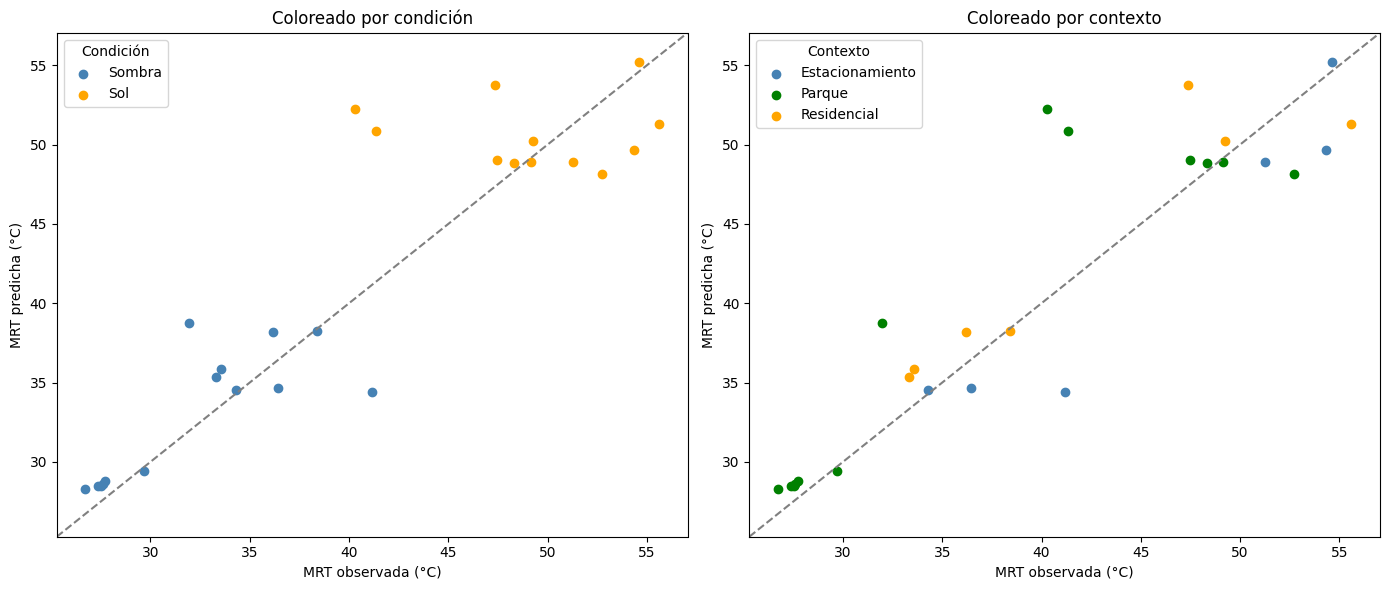

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = points_proj["MRT"]
y = points_proj["MRT_predicted"]

# 1) Condition
traduc_cond = {"sun": "Sol", "shadow": "Sombra", "SUN": "Sol", "SHADOW": "Sombra"}
colores_cond = {"Sol": "orange", "Sombra": "steelblue"}
for cond in points_proj["condition"].unique():
    mask = points_proj["condition"] == cond
    label = traduc_cond.get(cond, cond)
    axes[0].scatter(x[mask], y[mask], label=label, color=colores_cond.get(label))
axes[0].set_title("Coloreado por condición")
axes[0].set_xlabel("MRT observada (°C)")
axes[0].set_ylabel("MRT predicha (°C)")
axes[0].legend(title="Condición")

# 2) Context
traduc_ctx = {"open parking": "Estacionamiento", "park": "Parque", "residential": "Residencial"}
colores_ctx = {"Estacionamiento": "steelblue", "Parque": "green", "Residencial": "orange"}
for ctx in points_proj["context"].unique():
    mask = points_proj["context"] == ctx
    label = traduc_ctx.get(ctx, ctx)
    axes[1].scatter(x[mask], y[mask], label=label, color=colores_ctx.get(label))
axes[1].set_title("Coloreado por contexto")
axes[1].set_xlabel("MRT observada (°C)")
axes[1].set_ylabel("MRT predicha (°C)")
axes[1].legend(title="Contexto")

# 1:1 line
for ax in axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray", linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

In [39]:
# Scatter
fig = px.scatter(
    points_proj,
    x=pred,
    y=residuals,
    color="context",
    hover_data=["TG", "TA","wind_mean", "condition", "Instrument", "tg_corr", "MRT", "ID"],
)

# 1:1 line
fig.add_scatter(
    x=[pred.min(), pred.max()],
    y=[0, 0],
    mode="lines",
    name="Zero residual line"
)

fig.update_layout(
    xaxis_title="Predicted MRT °C",
    yaxis_title="Residuals (Obs - Pred)",
    title="points_proj residuals"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

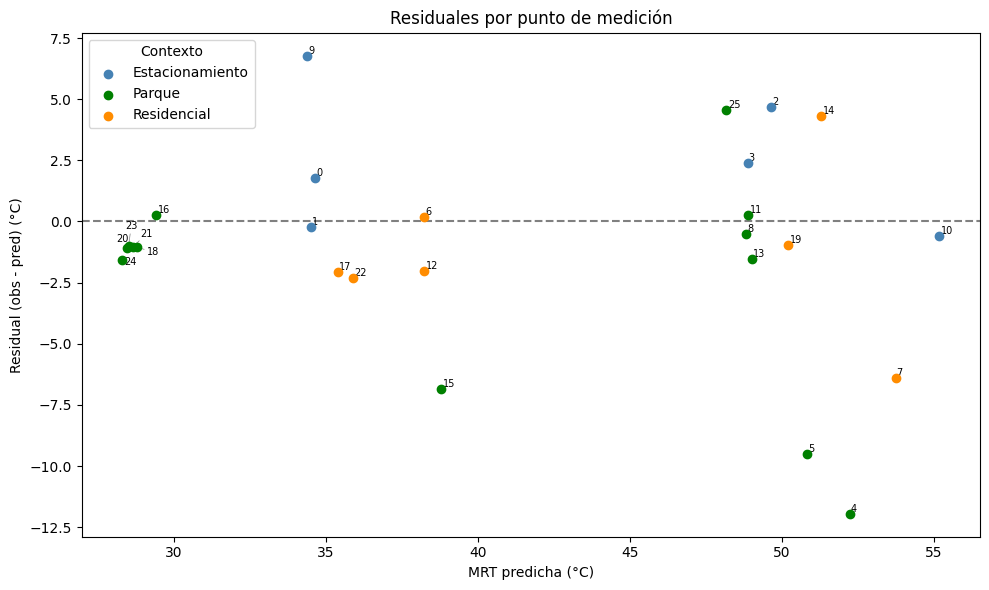

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

traduc_ctx = {"open parking": "Estacionamiento", "park": "Parque", "residential": "Residencial"}
colors = {"open parking": "steelblue", "park": "green", "residential": "darkorange"}

for ctx in points_proj["context"].unique():
    mask = points_proj["context"] == ctx
    ax.scatter(
        pred[mask], residuals[mask],
        label=traduc_ctx.get(ctx, ctx),
        color=colors.get(ctx, "gray"),
        zorder=5
    )

# Labels with adjust_text
texts = []
for idx, row in points_proj.iterrows():
    texts.append(ax.text(pred[idx], residuals[idx], str(row["ID"]), fontsize=7))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("MRT predicha (°C)")
ax.set_ylabel("Residual (obs - pred) (°C)")
ax.set_title("Residuales por punto de medición")
ax.legend(title="Contexto")
plt.tight_layout()
plt.show()

In [41]:
metrics_residual = (
    points_proj
    .groupby("context")["residuals"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        count="count",
        mae=lambda x: np.mean(np.abs(x)),
        rmse=lambda x: np.sqrt(np.mean(x**2))
    )
)

metrics_residual

,mean,std,min,max,count,mae,rmse
context,,,,,,,
open parking,2.474936,2.844548,-0.576636,6.777730,6,2.740161,3.587226
park,-2.382053,4.439086,-11.955201,4.546920,13,3.167733,4.885065
residential,-1.326500,3.206187,-6.381730,4.307221,7,2.605849,3.251264


In [42]:
df_plot = points_proj.drop(columns="geometry")

fig = px.box(
    df_plot,
    x="context",
    y="residuals",
    points="all",
    hover_data=["ID"],
)

fig.add_hline(y=0, line_dash="solid", line_color="black")

fig.update_layout(
    yaxis_title="Residual (obs-pred)",
    xaxis_title="",
    xaxis_tickangle=45
)

fig.update_traces(
    jitter=0,        # 0 = centered, 1 = spread out
    pointpos=0,      # 0 = inside the box, -1 or 1 = to the side
)
fig.show()

BEFORE STARTING, LOCATION OF SSOME POINTS WAS CORRECTED. SOME OF THEM WERE UNDER TREES NOT DETECTED:ALSO MOVED UNDER A DETECTED TREE.

10 AND 4 ARE OVERESTIMATED IN MODEL BECAUSE THERE IS DETECTED A BUILDING THAT DOESNT EXIST 


C:\Users\guada\AppData\Local\Temp\ipykernel_33680\1415995375.py:8: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



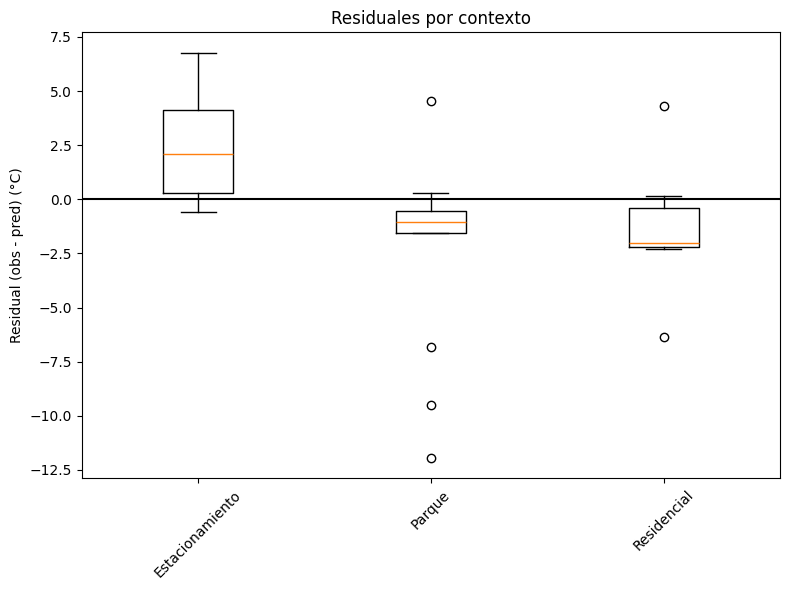

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))

traduc_ctx = {"open parking": "Estacionamiento", "park": "Parque", "residential": "Residencial"}

data = [points_proj[points_proj["context"] == ctx]["residuals"].dropna().values
        for ctx in traduc_ctx.keys()]

ax.boxplot(data, labels=traduc_ctx.values())
ax.axhline(0, color="black")
ax.set_ylabel("Residual (obs - pred) (°C)")
ax.set_title("Residuales por contexto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

comparing TA with MRT

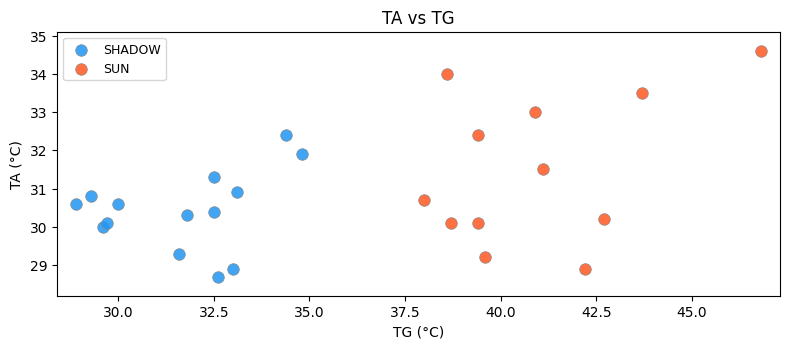

In [44]:
df = points_proj.copy().reset_index(drop=True)


colors = {"SHADOW": "#2196F3", "SUN": "#FF5722"}

fig, ax = plt.subplots(figsize=(8, 7))

for cond, group in df.groupby("condition"):
    ax.scatter(group["TG"], group["TA"],
               color=colors.get(cond, "gray"), s=70, zorder=3,
               edgecolors="gray", linewidths=0.5, label=cond, alpha=0.85)

ax.set_xlim(df["TG"].min() - 0.5, df["TG"].max() + 0.5)
ax.set_ylim(df["TA"].min() - 0.5, df["TA"].max() + 0.5)
ax.set_aspect("equal")

ax.set_xlabel("TG (°C)")
ax.set_ylabel("TA (°C)")
ax.set_title("TA vs TG", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

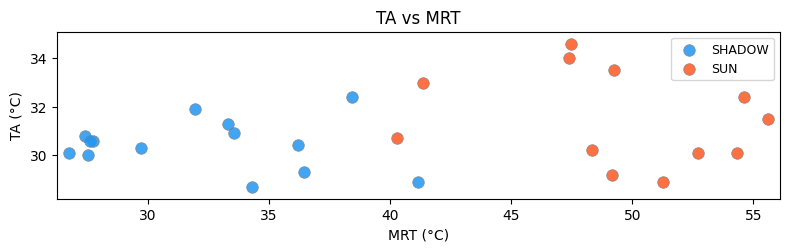

In [45]:


colors = {"SHADOW": "#2196F3", "SUN": "#FF5722"}

fig, ax = plt.subplots(figsize=(8, 7))

for cond, group in df.groupby("condition"):
    ax.scatter(group["MRT"], group["TA"],
               color=colors.get(cond, "gray"), s=70, zorder=3,
               edgecolors="gray", linewidths=0.5, label=cond, alpha=0.85)

ax.set_xlim(df["MRT"].min() - 0.5, df["MRT"].max() + 0.5)
ax.set_ylim(df["TA"].min() - 0.5, df["TA"].max() + 0.5)
ax.set_aspect("equal")

ax.set_xlabel("MRT (°C)")
ax.set_ylabel("TA (°C)")
ax.set_title("TA vs MRT", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

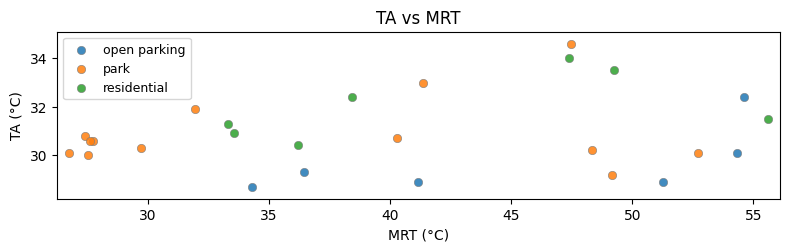

In [46]:
fig, ax = plt.subplots(figsize=(8, 7))

for cond, group in df.groupby("context"):
    ax.scatter(group["MRT"], group["TA"],
               edgecolors="gray", linewidths=0.5, label=cond, alpha=0.85)

ax.set_xlim(df["MRT"].min() - 0.5, df["MRT"].max() + 0.5)
ax.set_ylim(df["TA"].min() - 0.5, df["TA"].max() + 0.5)
ax.set_aspect("equal")

ax.set_xlabel("MRT (°C)")
ax.set_ylabel("TA (°C)")
ax.set_title("TA vs MRT", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()